In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter
import random

# set numpy prints to 4 decimal points
np.set_printoptions(precision=4, suppress=True)

DATA_PATH = r'C:\Users\user\Desktop\CV Training Guy\CV_training\computer_vision\course_resources\ps_4'

In [2]:
def img_int_to_float(img):
    """
    Convert an image from integer to float representation.
    """
    return img.astype(np.float32) / 255.0 if img.dtype == np.uint8 else img.astype(np.float32)


def img_float_to_int(img):
    """
    Convert an image from float to integer representation.
    """
    return (img * 255).astype(np.uint8) if img.dtype == np.float32 else img.astype(np.uint8)


def load_smooth(path, sigma=1):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    image = img_int_to_float(image)
    return gaussian_filter(image, sigma=sigma)


img_check = load_smooth(os.path.join(DATA_PATH, 'check.bmp'), sigma=0)
img_check_rot = load_smooth(os.path.join(DATA_PATH, 'check_rot.bmp'), sigma=0)
img_sim_a = load_smooth(os.path.join(DATA_PATH, 'simA.jpg'))
img_sim_b = load_smooth(os.path.join(DATA_PATH, 'simB.jpg'))
img_trans_a = load_smooth(os.path.join(DATA_PATH, 'transA.jpg'))
img_trans_b = load_smooth(os.path.join(DATA_PATH, 'transB.jpg'))

## 1 - Harris corners

In [3]:
def gradient_x(img):
    return skimage.filters.sobel_h(img)


def gradient_y(img):
    return skimage.filters.sobel_v(img)


def gradient_magnitude(img):
    return skimage.filters.sobel(img)


def gradient_orientation(img):
    return np.arctan2(gradient_y(img), gradient_x(img))

In [4]:
def plot_gradients(img):
    plt.figure(figsize=(12, 10))
    plot_imgs = [img, gradient_magnitude(img), gradient_x(img), gradient_y(img)]
    names = ['Original Image', 'Gradient Magnitude', 'Gradient X', 'Gradient Y']
    for idx, plot_img in enumerate(plot_imgs):
        plt.subplot(2, 2, idx + 1)
        plt.imshow(plot_img, cmap='gray')
        plt.axis('off')
        plt.title(names[idx])
        plt.colorbar()
    plt.show()

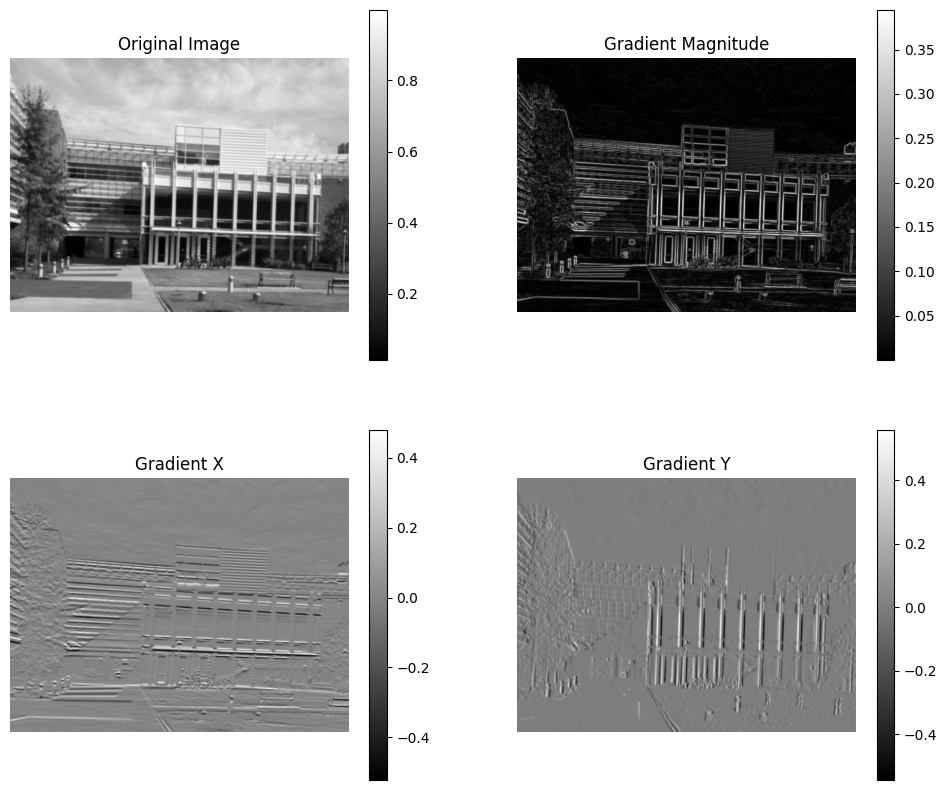

In [5]:
plot_gradients(img_trans_a)

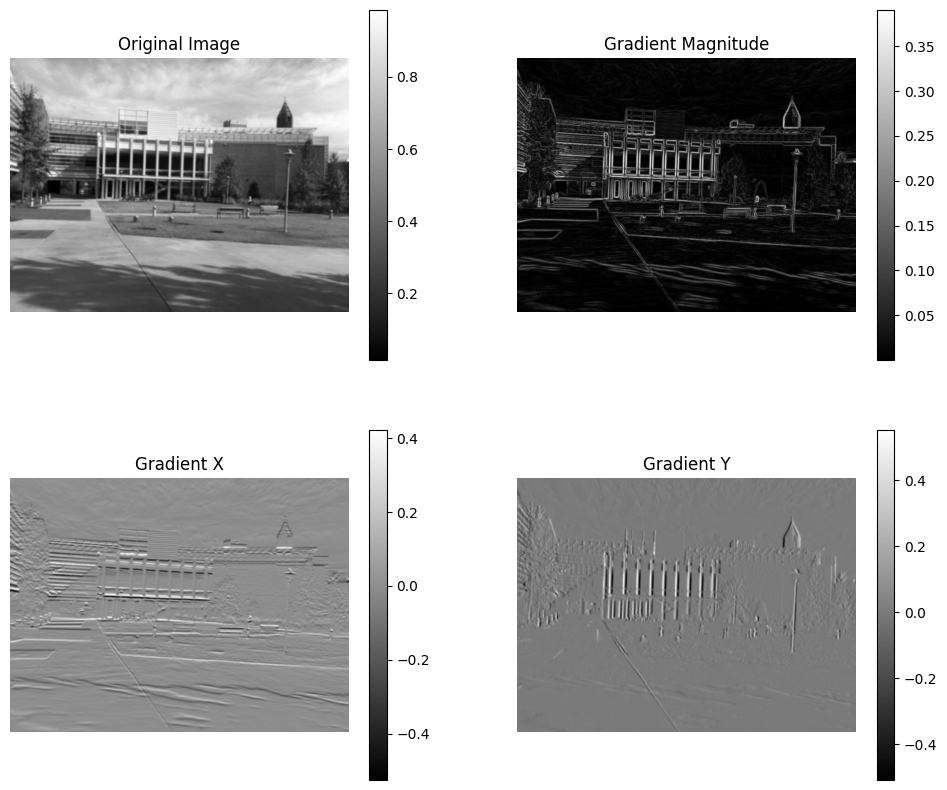

In [6]:
plot_gradients(img_sim_a)

In [7]:
def harris_response(img, k=0.04):
    Ix = gradient_x(img)
    Iy = gradient_y(img)

    Ixx = Ix * Ix
    Ixy = Ix * Iy
    Iyy = Iy * Iy

    Sxx = gaussian_filter(Ixx, sigma=1)
    Sxy = gaussian_filter(Ixy, sigma=1)
    Syy = gaussian_filter(Iyy, sigma=1)

    det = Sxx * Syy - Sxy * Sxy
    trace = Sxx + Syy

    return det - k * (trace ** 2)


def threshold_and_non_max_suppression(response, threshold=0.001, min_distance=5):
    response[response < threshold] = - np.inf
    return peak_local_max(response, min_distance=min_distance, threshold_abs=threshold)


def harris_corners(img, k=0.04, threshold=0.01, min_distance=5):
    response = harris_response(img, k)
    corners = threshold_and_non_max_suppression(response, threshold, min_distance)
    return corners


# def corner_img(img):
#     corners = harris_corners(img)
#     corner_img = np.zeros_like(img)
#     # corner is Nx2, use it to index into the image
#     corner_img[corners[:, 0], corners[:, 1]] = 1.0
#     return corner_img
#
def plot_img(img, title='Image', colorbar=False):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(title)
    if colorbar:
        plt.colorbar()


def draw_corners(img, corners, type='x'):
    img_with_corners = img.copy()
    if len(img_with_corners.shape) == 2:  # If the image is grayscale
        img_with_corners = cv2.cvtColor(img_with_corners, cv2.COLOR_GRAY2BGR)
    for corner in corners:
        if type == 'circle':
            cv2.circle(img_with_corners, tuple(corner[::-1]), radius=5, color=(0, 0, 255), thickness=2)
        elif type == 'x':
            cv2.drawMarker(img_with_corners, tuple(corner[::-1]), color=(0, 255, 0), thickness=3)
        else:
            raise ValueError("Unknown type: {}".format(type))
    return img_with_corners

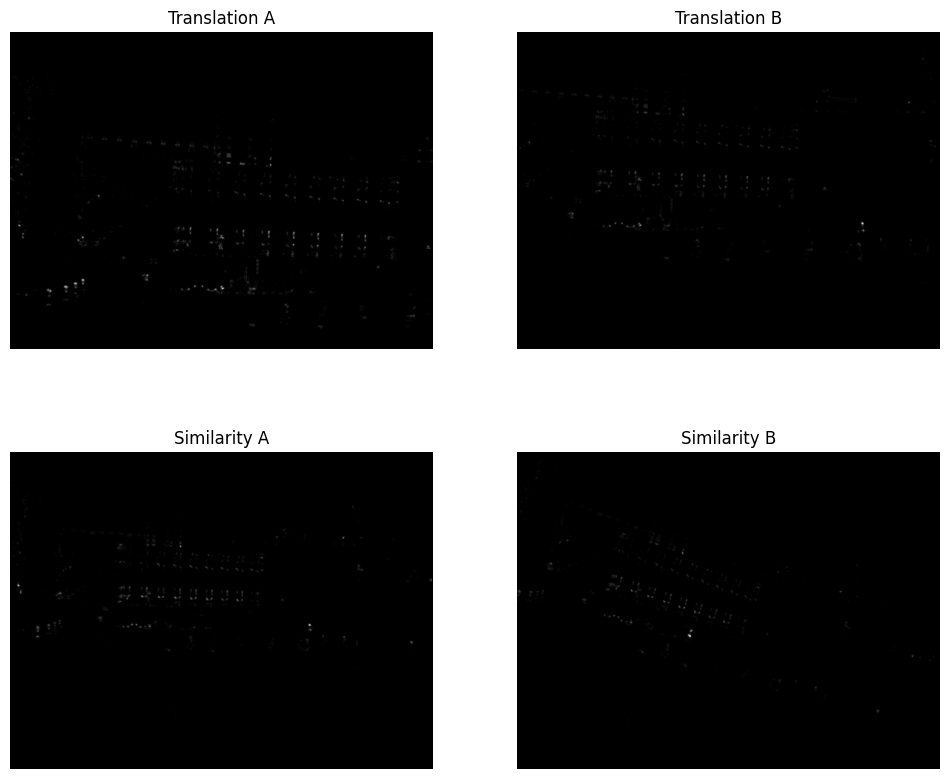

In [8]:
imgs = [img_trans_a, img_trans_b, img_sim_a, img_sim_b]
names = ['Translation A', 'Translation B', 'Similarity A', 'Similarity B']
plt.figure(figsize=(12, 10))
for idx, img in enumerate(imgs):
    img_response = harris_response(img, k=0.04)
    img_response[img_response < 0] = 0
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img_response, cmap='gray')
    plt.axis('off')
    plt.title(names[idx])
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


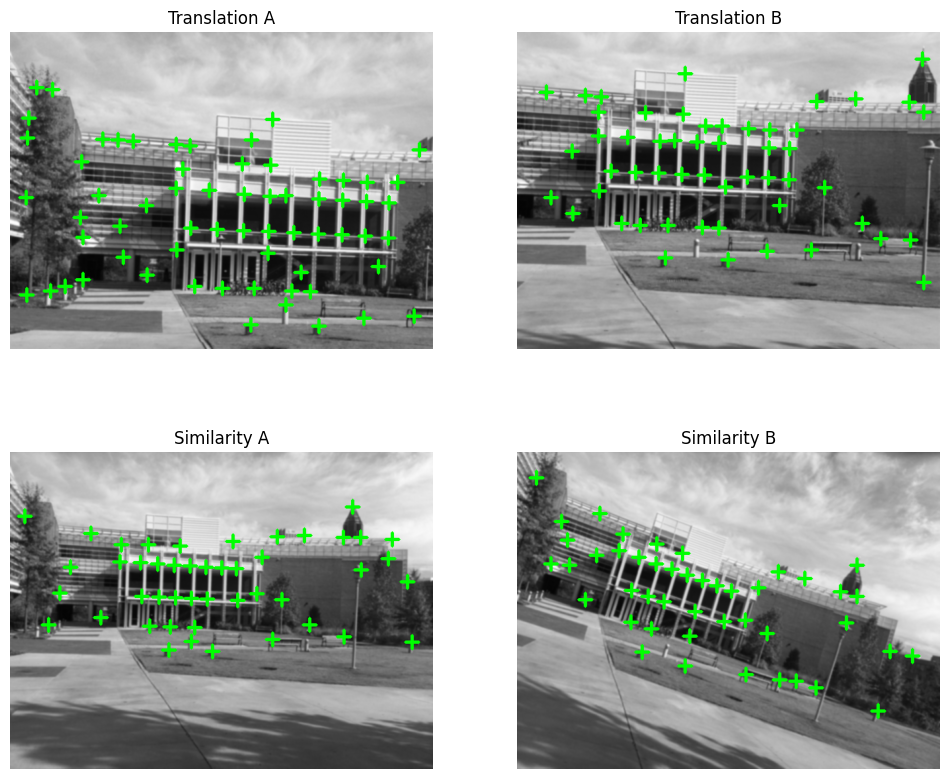

In [9]:
imgs = [img_trans_a, img_trans_b, img_sim_a, img_sim_b]
names = ['Translation A', 'Translation B', 'Similarity A', 'Similarity B']
plt.figure(figsize=(12, 10))
for idx, img in enumerate(imgs):
    corners = harris_corners(img, k=0.04, threshold=0.0001, min_distance=20)
    img_with_corners = draw_corners(img, corners)
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img_with_corners, cmap='gray')
    plt.axis('off')
    plt.title(names[idx])
plt.show()

## 2 - SIFT

In [10]:
def draw_arrows(img, pts, r=10):
    g_angle = gradient_orientation(img)
    angles = g_angle[pts[:, 0], pts[:, 1]]  # Get the gradient angles at the corner points
    # use cv2.drawkeypoints to draw arrows in pts according to g_angle
    img_with_arrows = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for pt, angle in zip(pts, angles):
        # print(angle)
        y, x = pt
        dx = r * np.cos(angle)
        dy = r * np.sin(angle)
        cv2.arrowedLine(img_with_arrows, (int(x), int(y)), (int(x + dx), int(y + dy)), (0, 255, 0), 3, tipLength=1.5)
    return img_with_arrows

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


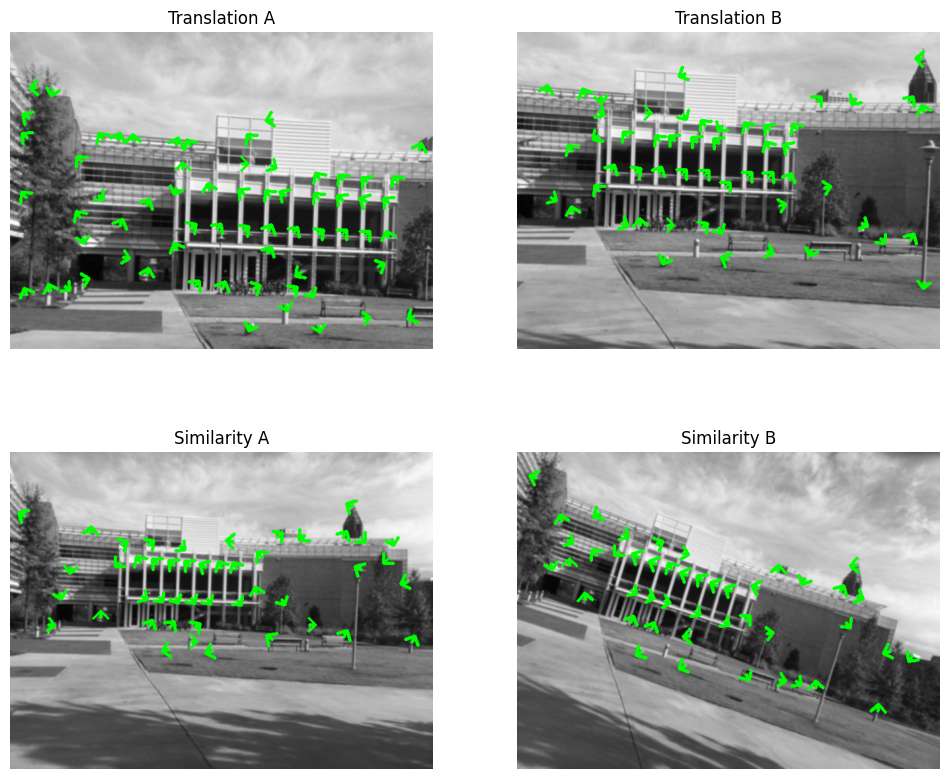

In [11]:
imgs = [img_trans_a, img_trans_b, img_sim_a, img_sim_b]
names = ['Translation A', 'Translation B', 'Similarity A', 'Similarity B']
plt.figure(figsize=(12, 10))
for idx, img in enumerate(imgs):
    c = harris_corners(img, k=0.04, threshold=0.0001, min_distance=20)
    img_arrows = draw_arrows(img, c, r=10)
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img_arrows, cmap='gray')
    plt.axis('off')
    plt.title(names[idx])
plt.show()

In [12]:
def compute_sift_keypoints(img):
    img = img_float_to_int(img)
    corner_points = harris_corners(img, k=0.04, threshold=0.0001, min_distance=20)
    points = [cv2.KeyPoint(x=int(p[1]), y=int(p[0]), size=3, angle=90, octave=0) for p in corner_points]
    sift = cv2.SIFT_create()
    points, descriptors = sift.compute(img, points)
    return points, descriptors


def match_sift_keypoints(d_a, d_b):
    bfm = cv2.BFMatcher()
    matches = bfm.match(d_a, d_b)
    return matches


def draw_sift_matches(img_a, img_b):
    # Compute keypoints and descriptors
    p_a, d_a = compute_sift_keypoints(img_a)
    p_b, d_b = compute_sift_keypoints(img_b)

    # Match descriptors
    matches = match_sift_keypoints(d_a, d_b)

    # Create an output image by placing the two images side by side
    h1, w1 = img_a.shape[:2]
    h2, w2 = img_b.shape[:2]
    out_img = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)

    # Convert to 3-channel if input images are grayscale
    if len(img_a.shape) == 2:
        img_a_color = img_float_to_int(cv2.cvtColor(img_a, cv2.COLOR_GRAY2BGR))
    else:
        img_a_color = img_a
    if len(img_b.shape) == 2:
        img_b_color = img_float_to_int(cv2.cvtColor(img_b, cv2.COLOR_GRAY2BGR))
    else:
        img_b_color = img_b

    out_img[:h1, :w1] = img_a_color
    out_img[:h2, w1:w1 + w2] = img_b_color

    # Draw lines between matching keypoints
    for match in matches:
        pt_a = tuple(np.round(p_a[match.queryIdx].pt).astype(int))
        pt_b = tuple(np.round(p_b[match.trainIdx].pt).astype(int) + np.array([w1, 0]))  # shift x by img_a width
        cv2.line(out_img, pt_a, pt_b, color=(0, 255, 0), thickness=2)

    # Draw keypoints
    for kp in p_a:
        pt = tuple(np.round(kp.pt).astype(int))
        cv2.circle(out_img, pt, radius=8, color=(255, 0, 0), thickness=-1)
    for kp in p_b:
        pt = tuple(np.round(kp.pt).astype(int) + np.array([w1, 0]))
        cv2.circle(out_img, pt, radius=8, color=(0, 0, 255), thickness=-1)

    return out_img

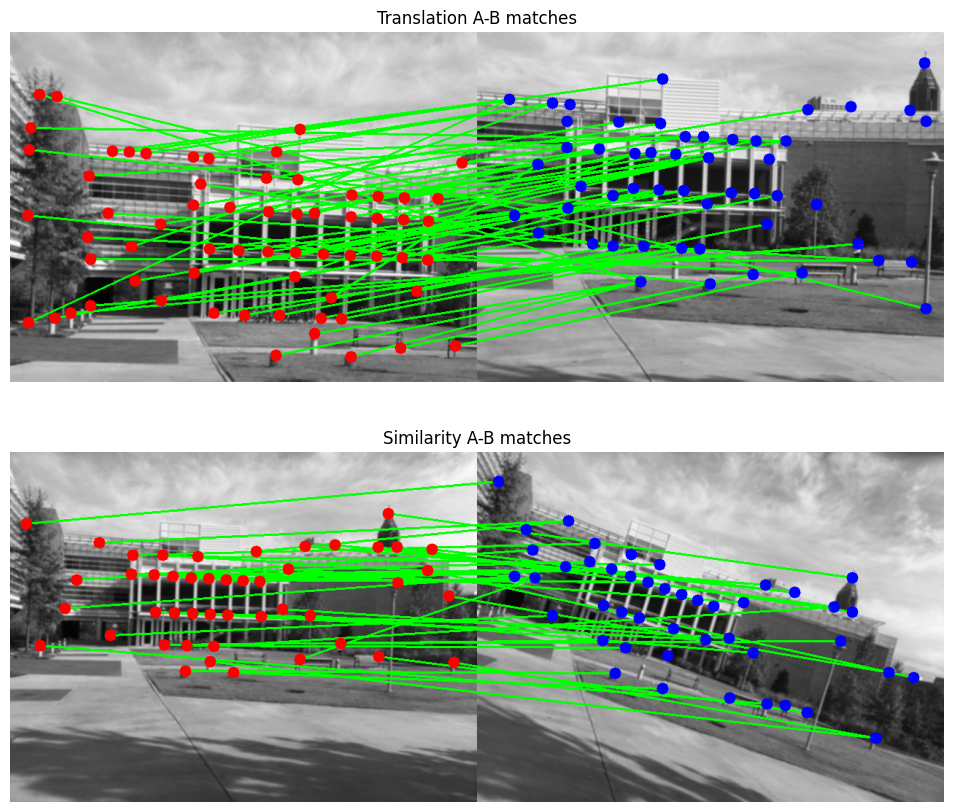

In [13]:
img_trans_matches = draw_sift_matches(img_trans_a, img_trans_b)
img_sim_matches = draw_sift_matches(img_sim_a, img_sim_b)
plt.figure(figsize=(20, 10))
plt.subplot(2, 1, 1)
plt.imshow(img_trans_matches)
plt.title('Translation A-B matches')
plt.axis('off')
plt.subplot(2, 1, 2)
plt.imshow(img_sim_matches)
plt.title('Similarity A-B matches')
plt.axis('off')
plt.show()

In [14]:
def to_homogeneous(pts):
    return np.hstack([pts, np.ones((pts.shape[0], 1))])


def from_homogeneous(pts_h):
    return (pts_h[:, :2].T / pts_h[:, 2]).T


def estimate_translation_homogeneous(src_pts, dst_pts):
    t = np.mean(dst_pts - src_pts, axis=0)
    T = np.eye(3)
    T[:2, 2] = t
    return T


def estimate_similarity_homogeneous(src_pts, dst_pts):
    src = np.asarray(src_pts)
    dst = np.asarray(dst_pts)
    x, y = src[:, 0], src[:, 1]
    xp, yp = dst[:, 0], dst[:, 1]

    A = np.zeros((4, 4))
    A[0::2, 0] = x
    A[0::2, 1] = -y
    A[0::2, 2] = 1
    A[1::2, 0] = y
    A[1::2, 1] = x
    A[1::2, 3] = 1

    Y = np.array([xp[0], yp[0], xp[1], yp[1]])
    params, *_ = np.linalg.lstsq(A, Y, rcond=None)
    a, b, c, d = params

    T = np.array([
        [a, -b, c],
        [b, a, d],
        [0, 0, 1]
    ])
    return T


def estimate_affine_homogeneous(src_pts, dst_pts):
    src = np.asarray(src_pts)
    dst = np.asarray(dst_pts)
    x, y = src[:, 0], src[:, 1]
    xp, yp = dst[:, 0], dst[:, 1]

    A = np.zeros((6, 6))
    A[0::2, 0] = x
    A[0::2, 1] = y
    A[0::2, 2] = 1
    A[1::2, 3] = x
    A[1::2, 4] = y
    A[1::2, 5] = 1

    Y = np.stack([xp, yp], axis=1).reshape(-1)
    params, *_ = np.linalg.lstsq(A, Y, rcond=None)
    a, b, c, d, e, f = params

    T = np.array([
        [a, b, c],
        [d, e, f],
        [0, 0, 1]
    ])
    return T


def apply_homogeneous(T, pts):
    pts_h = to_homogeneous(pts)
    pts_t = (T @ pts_h.T).T
    return from_homogeneous(pts_t)


def ransac_homogeneous(
        estimate_func,
        pts_a,
        pts_b,
        sample_size,
        threshold=3.0,
        num_iters=5000
):
    best_T = None
    best_inliers = []

    for _ in range(num_iters):
        idx = np.random.choice(len(pts_a), sample_size, replace=False)
        src_sample = pts_a[idx]
        dst_sample = pts_b[idx]

        try:
            T = estimate_func(src_sample, dst_sample)
        except Exception:
            continue

        pts_transformed = apply_homogeneous(T, pts_a)
        dists = np.linalg.norm(pts_b - pts_transformed, axis=1)
        inliers = np.where(dists < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_T = T

    return best_T, best_inliers


In [15]:
def draw_matches(img_a, kp_a, img_b, kp_b, matches, match_mask=None):
    """
    Utility to draw matches between keypoints of two images.
    If match_mask is given, only those matches are drawn.
    """
    return cv2.drawMatches(
        img_float_to_int(img_a), kp_a,
        img_float_to_int(img_b), kp_b,
        matches,
        None,
        matchColor=(0, 255, 0),
        singlePointColor=(255, 0, 0),
        matchesMask=match_mask,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )


def draw_sift_matches(img_a, img_b, estimate_func, sample_size, threshold=5.0, num_iters=5000):
    kp_a, des_a = compute_sift_keypoints(img_a)
    kp_b, des_b = compute_sift_keypoints(img_b)

    matches = match_sift_keypoints(des_a, des_b)
    out_all = draw_matches(img_a, kp_a, img_b, kp_b, matches)

    # Extract matched keypoints
    pts_a = np.float32([kp_a[m.queryIdx].pt for m in matches])
    pts_b = np.float32([kp_b[m.trainIdx].pt for m in matches])

    # RANSAC
    T, inlier_indices = ransac_homogeneous(
        estimate_func=estimate_func,
        pts_a=pts_a,
        pts_b=pts_b,
        sample_size=sample_size,
        threshold=threshold,
        num_iters=num_iters
    )

    # Mask for drawing inliers only
    match_mask = [0] * len(matches)
    for i in inlier_indices:
        match_mask[i] = 1

    out_inliers = draw_matches(img_a, kp_a, img_b, kp_b, matches, match_mask)

    return out_all, out_inliers, T


def plot_match_results(out_all, out_inliers):
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.imshow(out_all)
    plt.title('All Matches')
    plt.axis('off')

    plt.subplot(2, 1, 2)
    plt.imshow(out_inliers)
    plt.title('RANSAC Inliers')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


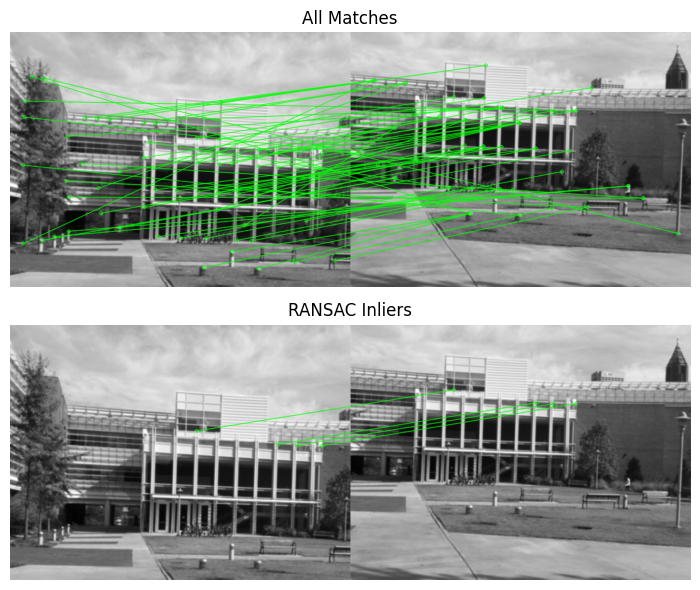

In [17]:
out_all_trans, out_inliers_trans, T_trans = draw_sift_matches(
    img_trans_a, img_trans_b,
    estimate_func=estimate_translation_homogeneous,
    sample_size=10
)
plot_match_results(out_all_trans, out_inliers_trans)

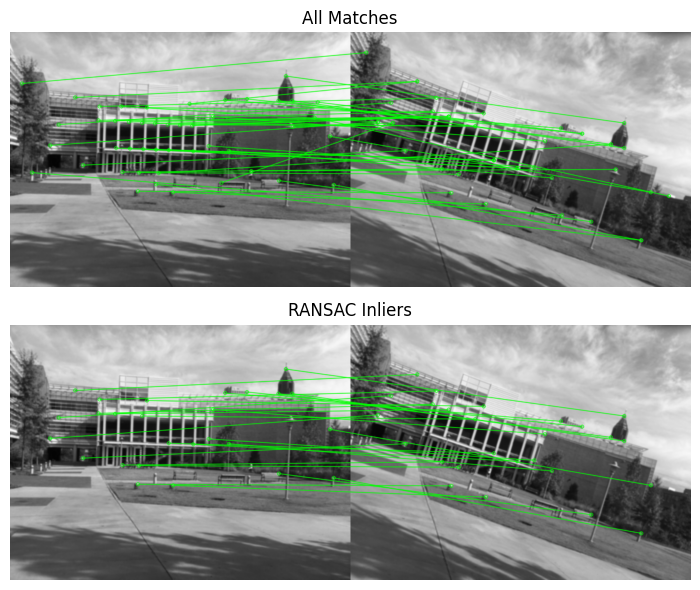

In [18]:
out_all_sim, out_inliers_sim, T_sim = draw_sift_matches(
    img_sim_a, img_sim_b,
    estimate_func=estimate_similarity_homogeneous,
    sample_size=2
)
plot_match_results(out_all_sim, out_inliers_sim)

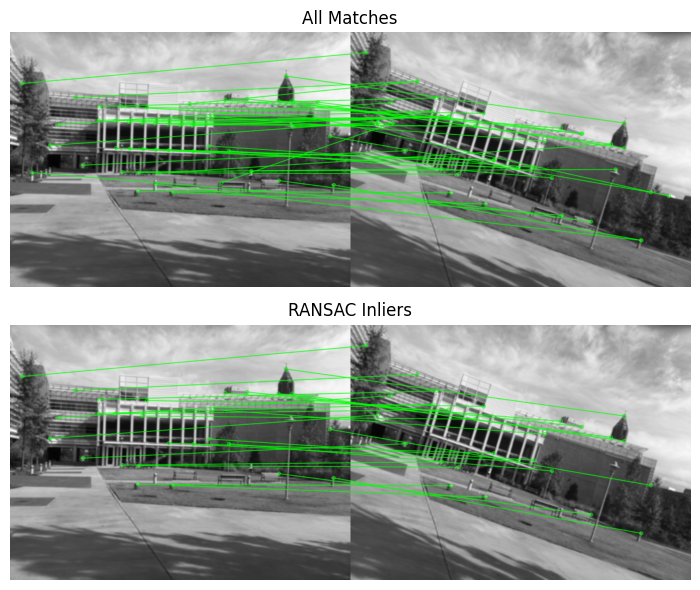

In [19]:
out_all_affine, out_inliers_affine, T_aff = draw_sift_matches(
    img_sim_a, img_sim_b,
    estimate_func=estimate_affine_homogeneous,
    sample_size=3
)
plot_match_results(out_all_affine, out_inliers_affine)

Lets try similarity on the translation image as translation transformation alone isn't perfect.

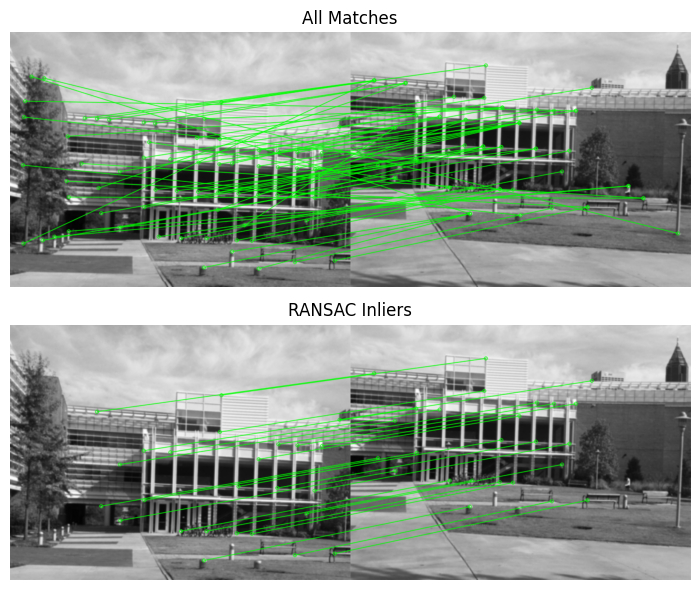

In [20]:
out_all_trans_new, out_inliers_trans_new, T_trans_new = draw_sift_matches(
    img_trans_a, img_trans_b,
    estimate_func=estimate_similarity_homogeneous,
    sample_size=2
)
plot_match_results(out_all_trans_new, out_inliers_trans_new)

In [21]:
print(f'T_trans:\n {T_trans}')
print(f'T_sim:\n {T_sim}')
print(f'T_affine:\n {T_aff}')
print(f'T_trans_new:\n {T_trans_new}')

T_trans:
 [[   1.     0.  -158.4]
 [   0.     1.   -78.4]
 [   0.     0.     1. ]]
T_sim:
 [[  0.9635  -0.2832  41.7723]
 [  0.2832   0.9635 -57.6464]
 [  0.       0.       1.    ]]
T_affine:
 [[  0.9621  -0.253   36.9624]
 [  0.2876   0.9679 -59.2773]
 [  0.       0.       1.    ]]
T_trans_new:
 [[   0.8959    0.0045 -103.2512]
 [  -0.0045    0.8959  -53.5057]
 [   0.        0.        1.    ]]


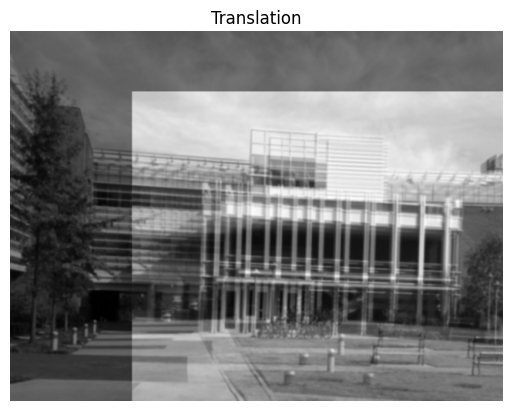

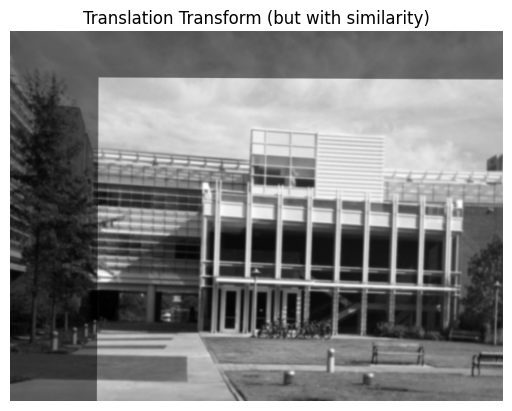

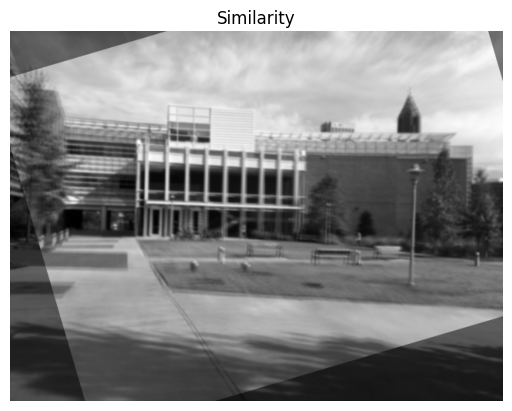

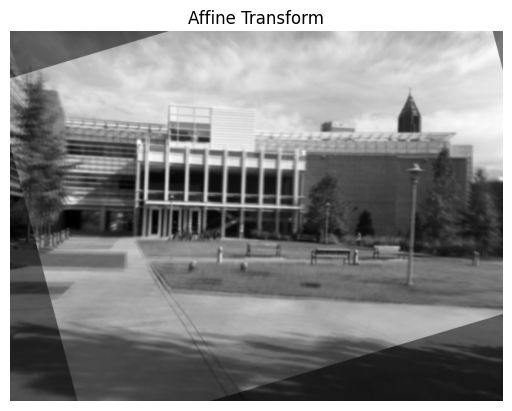

In [23]:
def warp_and_blend(img_a, img_b, T_a_to_b):
    T_b_to_a = np.linalg.inv(T_a_to_b)
    h, w = img_a.shape[:2]
    warped_b = cv2.warpPerspective(img_b, T_b_to_a, (w, h))
    blended = cv2.addWeighted(img_a, 0.5, warped_b, 0.5, 0)
    return blended

plot_img(warp_and_blend(img_trans_a, img_trans_b, T_trans), title='Translation')
plt.show()
plot_img(warp_and_blend(img_trans_a, img_trans_b, T_trans_new), title='Translation Transform (but with similarity)')
plt.show()
plot_img(warp_and_blend(img_sim_a, img_sim_b, T_sim), title='Similarity')
plt.show()
plot_img(warp_and_blend(img_sim_a, img_sim_b, T_aff), title='Affine Transform')
plt.show()